# **Telecom X - Parte 2: Predicción de Cancelación de Clientes**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests

#PROCESAMIENTO DE DATOS

## 1. Extracción del Archivo Tratado


### 1.1 Carga de los datos


In [ ]:
#URL de la API (CSV)
url = "https://github.com/memo7499/challenge-telecom-x-2/raw/main/data/df_limpio_telecomX.csv"

In [ ]:
#Hacemos el request de la API y verificamos que la respuesta sea correcta si el status code es 200
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors

# Leemos el contenido de la respuesta directamente en un DataFrame de pandas
from io import StringIO
df = pd.read_csv(StringIO(response.text))

In [ ]:
df.sample(5)

,id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,daily_charges
5889,8050-DVOJX,0.0,Male,1,0,0,49,1,1.0,DSL,...,1.0,1.0,0.0,1.0,Two year,0,Credit card (automatic),81.35,4060.90,2.71
5666,7740-KKCXF,0.0,Male,0,1,0,51,0,NaN,DSL,...,0.0,0.0,0.0,0.0,Month-to-month,1,Credit card (automatic),30.05,1529.45,1.00
2559,3570-YUEKJ,0.0,Female,0,0,0,42,1,0.0,DSL,...,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,49.55,2077.95,1.65
1807,2576-HXMPA,0.0,Female,0,0,0,1,1,0.0,No,...,NaN,NaN,NaN,NaN,Month-to-month,0,Credit card (automatic),19.55,19.55,0.65
811,1150-FTQGN,0.0,Female,0,1,1,60,1,1.0,Fiber optic,...,0.0,0.0,1.0,0.0,One year,0,Bank transfer (automatic),94.15,5811.80,3.14


### 1.2 Exploración Inicial del Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7267 non-null   object 
 1   churn              7043 non-null   float64
 2   gender             7267 non-null   object 
 3   senior_citizen     7267 non-null   int64  
 4   partner            7267 non-null   int64  
 5   dependents         7267 non-null   int64  
 6   tenure             7267 non-null   int64  
 7   phone_service      7267 non-null   int64  
 8   multiple_lines     6560 non-null   float64
 9   internet_service   7267 non-null   object 
 10  online_security    5686 non-null   float64
 11  online_backup      5686 non-null   float64
 12  device_protection  5686 non-null   float64
 13  tech_support       5686 non-null   float64
 14  streaming_tv       5686 non-null   float64
 15  streaming_movies   5686 non-null   float64
 16  contract           7267 

In [ ]:
df.shape

(7267, 22)

In [ ]:
df.columns

Index(['id', 'churn', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'daily_charges'],
      dtype='object')

In [ ]:
df.describe(include='all')

,id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,daily_charges
count,7267,7043.000000,7267,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,6560.000000,7267,...,5686.000000,5686.000000,5686.000000,5686.000000,7267,7267.000000,7267,7267.000000,7256.000000,7267.000000
unique,7267,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,Fiber optic,...,NaN,NaN,NaN,NaN,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,3675,NaN,NaN,NaN,NaN,NaN,NaN,3198,...,NaN,NaN,NaN,NaN,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,0.265370,NaN,0.162653,0.484106,0.300124,32.346498,0.902711,0.467226,NaN,...,0.438094,0.370032,0.490679,0.495251,NaN,0.593230,NaN,64.720098,2280.634213,2.157292
std,NaN,0.441561,NaN,0.369074,0.499782,0.458343,24.571773,0.296371,0.498963,NaN,...,0.496196,0.482855,0.499957,0.500021,NaN,0.491265,NaN,30.129572,2268.632997,1.004407
min,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,18.250000,18.800000,0.610000
25%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,35.425000,400.225000,1.180000
50%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,70.300000,1391.000000,2.340000
75%,NaN,1.000000,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,NaN,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,89.875000,3785.300000,2.995000


### 1.3 Tratando datos nulos

Antes de avanzar al análisis y modelado, se realizó un tratamiento estructurado de valores nulos, diferenciando su naturaleza según el tipo de variable:

- Variables de servicios: los valores nulos representan ausencia del servicio contratado.
- Variables categóricas: imputación con la moda.
- Variables numéricas: imputación con la mediana para reducir el impacto de valores extremos.

Este enfoque busca preservar la información original del cliente y evitar introducir sesgos artificiales en el modelo.


In [ ]:
#Verifricamos los datos nulos
# Conteo de nulos por columna
nulls = df.isna().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
print(nulls)

# Porcentaje
null_pct = (df.isna().mean()*100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(null_pct)

streaming_tv         1581
streaming_movies     1581
online_security      1581
online_backup        1581
device_protection    1581
tech_support         1581
multiple_lines        707
churn                 224
total_charges          11
dtype: int64
streaming_tv         21.755883
streaming_movies     21.755883
online_security      21.755883
online_backup        21.755883
device_protection    21.755883
tech_support         21.755883
multiple_lines        9.728912
churn                 3.082427
total_charges         0.151369
dtype: float64


In [ ]:
columnas_servicios = [
    'multiple_lines', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'
]

for col in columnas_servicios:
    df[col] = df[col].fillna('No')

In [ ]:
columnas_categóricas = df.select_dtypes(include='object').columns

for col in columnas_categóricas:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
columnas_numericas = df.select_dtypes(include=['int64','float64']).columns

for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

#### Variable objetivo (Churn)

La variable objetivo presenta un pequeño porcentaje de valores nulos (~3%).  
Dado que no es posible inferir de forma confiable si un cliente canceló o no, estos registros fueron eliminados para evitar contaminación del modelo.

In [ ]:
df = df.dropna(subset=['churn'])

In [ ]:
# Verificación final de valores nulos
df.isna().sum().sum()

np.int64(0)

✅ Resultado: el dataset queda completamente libre de valores nulos y listo para análisis estadístico y modelado predictivo.

In [ ]:
df.describe()
df['churn'].value_counts(normalize=True)

,proportion
churn,
0.0,0.74281
1.0,0.25719


#### Conclusión del tratamiento de datos nulos

El tratamiento de valores faltantes se realizó de manera diferenciada según la naturaleza de cada variable, priorizando la coherencia de negocio y la robustez estadística. El dataset resultante conserva la estructura original del problema y se encuentra preparado para análisis exploratorio, correlaciones y modelos de machine learning.

## 2. Eliminación de variables irrelevantes



Antes de construir los modelos predictivos, se eliminaron variables que no aportan valor analítico o pueden introducir ruido en el entrenamiento.

- Identificadores únicos (como `id`) no contienen información predictiva.
- Estas variables pueden generar sobreajuste o afectar negativamente el desempeño del modelo.

El objetivo es conservar únicamente variables con potencial explicativo sobre la cancelación de clientes (churn).


In [ ]:
# Eliminamos columna identificadora
df = df.drop(columns=['id'])

In [ ]:
df.columns

Index(['churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'daily_charges'],
      dtype='object')

In [ ]:
# Columnas con un solo valor (sin variabilidad)
cols_constantes = [col for col in df.columns if df[col].nunique() == 1]
cols_constantes

[]

# PREPARACIÓN Y MODELADO

#1. Codificación de variables categóricas (Encoding)

Los modelos de Machine Learning requieren variables numéricas. Por ello, las variables categóricas se transforman siguiendo estas reglas:

- Variables binarias → codificación 0/1
- Variables categóricas con múltiples niveles → One-Hot Encoding
- Se elimina una categoría de referencia para evitar multicolinealidad
- Se mantiene interpretabilidad del modelo

Con esto, el dataset queda listo para análisis estadístico y modelos predictivos.

In [ ]:
df.select_dtypes(include='object').nunique().sort_values()

,0
gender,2
multiple_lines,3
internet_service,3
online_security,3
online_backup,3
device_protection,3
tech_support,3
streaming_tv,3
streaming_movies,3
contract,3


In [ ]:
df["contract"].value_counts(dropna=False)

,count
contract,
Month-to-month,4005
Two year,1743
One year,1519


##Aplicamos un Ordinal Encoding a la vartiable `contract` para evitar errores de codificación

In [ ]:
#Asiganmos los valores numéricos por contrato
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
#Utilizamos .map() para asignar los valores anteriores y verificamos
df["contract"] = df["contract"].map(contract_map)

In [ ]:
df["contract"].dtype

dtype('int64')

In [ ]:
df["contract"].unique()

array([1, 0, 2])

In [ ]:
df["contract"].isna().sum()

np.int64(0)

In [ ]:
df_model = df.copy()

In [ ]:
df_model.columns

Index(['churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'daily_charges'],
      dtype='object')

In [ ]:
df_model.shape

(7267, 21)

## Aplicamos One-Hot Encoding

In [ ]:
ohe_cols = [
    'gender',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'payment_method'
]

In [ ]:
[col for col in ohe_cols if col in df_model.columns]

['gender',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'payment_method']

In [ ]:
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

In [ ]:
df_model

,churn,senior_citizen,partner,dependents,tenure,phone_service,contract,paperless_billing,monthly_charges,total_charges,...,device_protection_No,tech_support_1.0,tech_support_No,streaming_tv_1.0,streaming_tv_No,streaming_movies_1.0,streaming_movies_No,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0.0,0,1,1,9,1,1,1,65.60,593.30,...,False,True,False,True,False,False,False,False,False,True
1,0.0,0,0,0,9,1,0,0,59.90,542.40,...,False,False,False,False,False,True,False,False,False,True
2,1.0,0,0,0,4,1,0,1,73.90,280.85,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1,1,0,13,1,0,1,98.00,1237.85,...,False,False,False,True,False,True,False,False,True,False
4,1.0,1,1,0,3,1,0,1,83.90,267.40,...,False,True,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0.0,0,0,0,13,1,1,0,55.15,742.90,...,False,True,False,False,False,False,False,False,False,True
7263,1.0,0,1,0,22,1,0,1,85.10,1873.70,...,False,False,False,False,False,True,False,False,True,False
7264,0.0,0,0,0,2,1,0,1,50.30,92.75,...,False,False,False,False,False,False,False,False,False,True
7265,0.0,0,1,1,67,1,2,0,67.85,4627.65,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
df_model.shape

(7267, 31)

In [ ]:
df_model.select_dtypes(include='object').columns

Index([], dtype='object')

In [ ]:
df_model.isna().sum().sum()

np.int64(0)

# 2 Definición de Variable Objetivo (Target)

En esta etapa se separa la variable objetivo (*target*) del resto de variables predictoras (*features*).

La variable **`churn`** representa si el cliente canceló el servicio (1) o permaneció (0), por lo que será la variable a predecir en los modelos de Machine Learning.

Se crean:

- **X** → Variables independientes (features)
- **y** → Variable dependiente (target)

Esta separación es necesaria para entrenar modelos predictivos supervisados.


In [ ]:
X = df_model.drop('churn', axis=1)
y = df_model['churn']

## Distribución de la Variable Objetivo

Antes de entrenar modelos, es importante analizar la proporción de clases.  
Un desbalance significativo puede afectar el desempeño del modelo y requerir técnicas especiales como *class weighting*, *resampling* o métricas adecuadas.

Se evalúa la proporción de clientes que permanecen vs. los que cancelan el servicio.


In [ ]:
X.shape

(7267, 30)

In [ ]:
y.shape

(7267,)

In [ ]:
proporcion_churn= y.value_counts(normalize=True)
proporcion_churn

,proportion
churn,
0.0,0.74281
1.0,0.25719


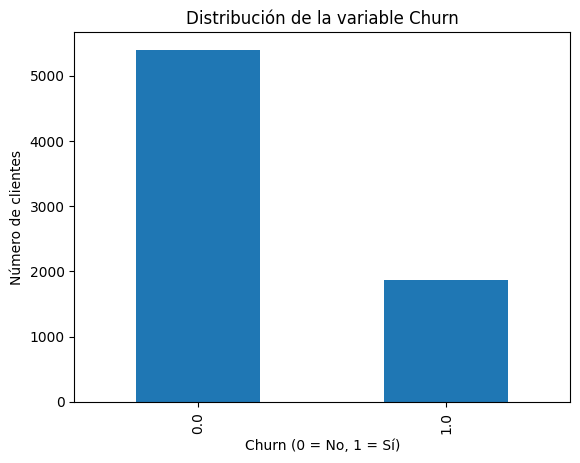

In [ ]:
# Gráfico de barras de la distribución de churn
df_model["churn"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Número de clientes")
plt.show()


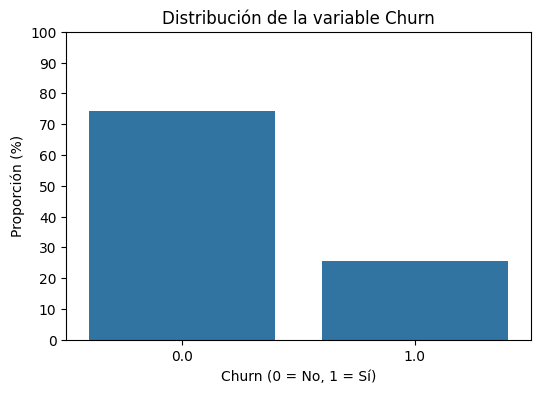

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=proporcion_churn.index, y=proporcion_churn.values * 100)
plt.title("Distribución de la variable Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Proporción (%)")
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 10))
plt.show()

## 5. Separación de Datos: Entrenamiento y Prueba

Para evaluar correctamente el desempeño de los modelos de Machine Learning, el dataset se divide en dos subconjuntos:

- **Entrenamiento (Train)** → utilizado para entrenar el modelo
- **Prueba (Test)** → utilizado para evaluar su capacidad de generalización

Se utiliza una división **80/20** con **estratificación**, asegurando que la proporción de churn se mantenga en ambos conjuntos. Esto es especialmente importante en problemas con clases desbalanceadas.


In [ ]:
# Importar función para dividir el dataset
from sklearn.model_selection import train_test_split

# Dividir en entrenamiento y prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape

((5813, 30), (1454, 30))

### Validación de la Estratificación

Se verifica que la proporción de churn se conserve tanto en el conjunto de entrenamiento como en el de prueba, garantizando una evaluación justa del modelo.

In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

,proportion
churn,
0.0,0.742779
1.0,0.257221


In [ ]:
X_train.shape, X_test.shape

((5813, 30), (1454, 30))

### Balanceo de Clases con SMOTE

Dado que el objetivo del negocio es maximizar la detección de clientes que podrían cancelar el servicio, se aplica SMOTE (Synthetic Minority Over-sampling Technique) sobre el conjunto de entrenamiento.

Esta técnica genera ejemplos sintéticos de la clase minoritaria, permitiendo que el modelo aprenda mejor sus patrones y mejore el recall. No odificamos el conjunto de prueba para mantener una evaluación realista del modelo.

In [ ]:
# Importar SMOTE
from imblearn.over_sampling import SMOTE

# Inicializar con semilla para reproducibilidad
smote = SMOTE(random_state=42)

In [ ]:
# Aplicar balanceo SOLO sobre entrenamiento
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [ ]:
# Verificar distribución antes y después
y_train.value_counts()
y_train_bal.value_counts()

,count
churn,
0.0,4318
1.0,4318


### Comparación de Distribución de Clases: Antes vs Después de SMOTE

Se compara la distribución de la variable objetivo en el conjunto de entrenamiento antes y después de aplicar SMOTE, con el fin de visualizar el impacto del balanceo.

In [ ]:
# Conteo antes del balanceo
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

print("\nDistribución después de SMOTE:")
print(y_train_bal.value_counts())

Distribución antes de SMOTE:
churn
0.0    4318
1.0    1495
Name: count, dtype: int64

Distribución después de SMOTE:
churn
0.0    4318
1.0    4318
Name: count, dtype: int64


In [ ]:
# Proporciones antes
y_train.value_counts(normalize=True)

,proportion
churn,
0.0,0.742818
1.0,0.257182


In [ ]:
# Proporciones después
y_train_bal.value_counts(normalize=True)

,proportion
churn,
0.0,0.5
1.0,0.5


## 6. Análisis de correlación

Se analiza la relación lineal entre las variables predictoras y la variable objetivo (`churn`) utilizando el coeficiente de correlación de Pearson.

Este análisis permite:

- Identificar variables con mayor asociación con la cancelación.
- Detectar relaciones positivas y negativas.
- Fundamentar el uso de modelos lineales como la regresión logística.
- Detectar posibles problemas de multicolinealidad.

### Matriz de correlación


In [ ]:
# Calcular matriz de correlación
corr_matrix = df_model.corr()

In [ ]:
# Extraer correlación específica con churn
corr_with_churn = corr_matrix['churn'].sort_values(ascending=False)
corr_with_churn

,churn
churn,1.000000
internet_service_Fiber optic,0.300949
payment_method_Electronic check,0.294626
daily_charges,0.189918
monthly_charges,0.189866
paperless_billing,0.186666
senior_citizen,0.146733
streaming_tv_1.0,0.062430
streaming_movies_1.0,0.060586
multiple_lines_1.0,0.039343


In [ ]:
# Top correlaciones positivas
corr_with_churn.head(10)

# Top correlaciones negativas
corr_with_churn.tail(10)

,churn
total_charges,-0.194016
online_backup_No,-0.224051
device_protection_No,-0.224051
tech_support_No,-0.224051
internet_service_No,-0.224051
online_security_No,-0.224051
streaming_tv_No,-0.224051
streaming_movies_No,-0.224051
tenure,-0.344079
contract,-0.387433


### Variables más influyentes

In [ ]:
# Top correlaciones positivas
corr_with_churn.head(10)

,churn
churn,1.000000
internet_service_Fiber optic,0.300949
payment_method_Electronic check,0.294626
daily_charges,0.189918
monthly_charges,0.189866
paperless_billing,0.186666
senior_citizen,0.146733
streaming_tv_1.0,0.062430
streaming_movies_1.0,0.060586
multiple_lines_1.0,0.039343


In [ ]:
# Top correlaciones negativas
corr_with_churn.tail(10)

,churn
total_charges,-0.194016
online_backup_No,-0.224051
device_protection_No,-0.224051
tech_support_No,-0.224051
internet_service_No,-0.224051
online_security_No,-0.224051
streaming_tv_No,-0.224051
streaming_movies_No,-0.224051
tenure,-0.344079
contract,-0.387433


###Visualización

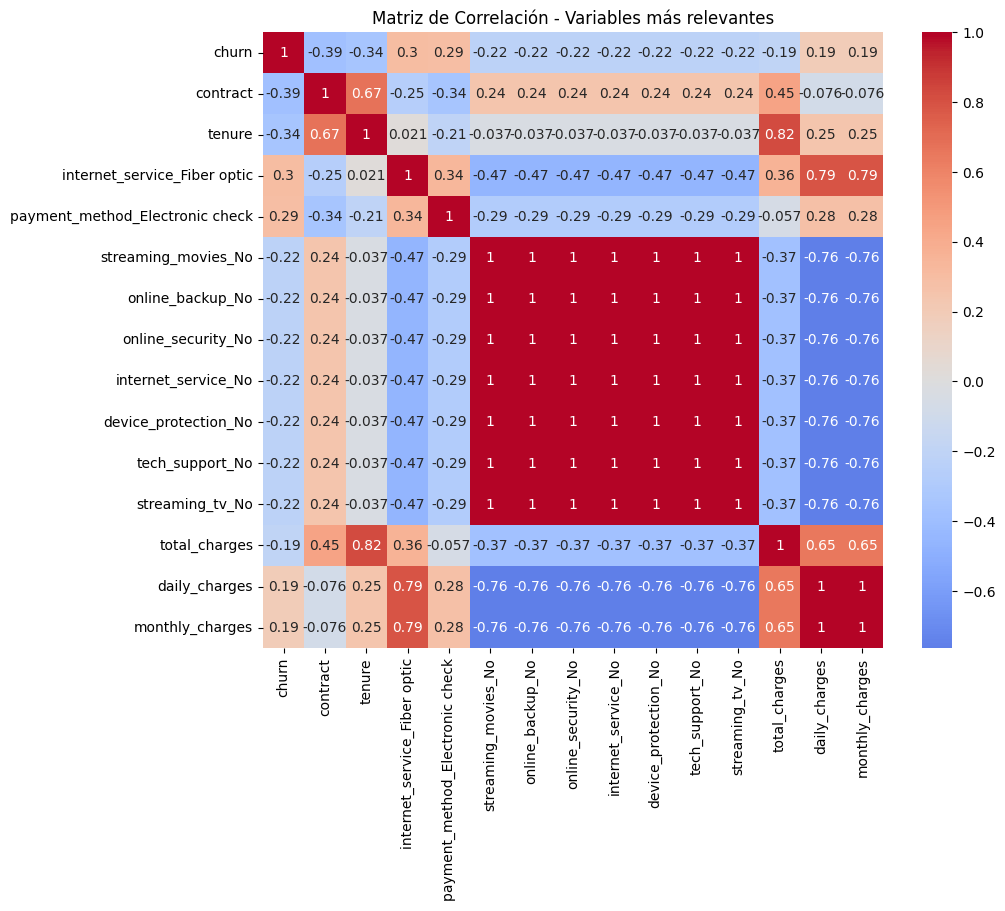

In [ ]:
# Seleccionamos solo las 15 variables más correlacionadas con churn
top_features = corr_with_churn.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))
sns.heatmap(df_model[top_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación - Variables más relevantes")
plt.show()

###Observaciones

####A) Variables con mayor correlación positiva con churn

📊 Según el heatmap:

-  internet_service_Fiber optic (~ +0.30)
-  payment_method_Electronic check (~ +0.29)
-  daily_charges / monthly_charges (~ +0.19)

🔎 Interpretación:

- Fibra óptica → mayor churn
  - Posible hipótesis: clientes de fibra pagan más → mayor sensibilidad a precio.
  - Puede indicar competencia fuerte en ese segmento.

- Electronic check → mayor churn
  - Perfil de cliente menos estable.
  - Puede correlacionar con menor compromiso - contractual.

- Cargos mensuales altos → mayor churn
  - Lógico económicamente.
  - A mayor costo, mayor probabilidad de cancelación.

####B) Variables con mayor correlación negativa con churn

📊 Según el heatmap:

- contract (~ -0.39)
- tenure (~ -0.34)

🔎 Interpretación:

- Contract (ordinal) negativo
  - A mayor duración de contrato → menor churn.
  - Es el factor protector más fuerte del dataset.

- Tenure
  - A mayor tiempo con la empresa → menor probabilidad de cancelación.
  - Clásico patrón de lealtad acumulada.

###Conclusión

- Las variables más influyentes son:
  - Contract
  - Tenure
  - Tipo de internet
  - Método de pago
  - Nivel de cargos

- Eso significa que churn está dominado por:
  - Compromiso contractual
  - Antigüedad
  - Precio
  - Tipo de servicio

## 7. Análisis dirigido

#### **Tenure vs Churn**

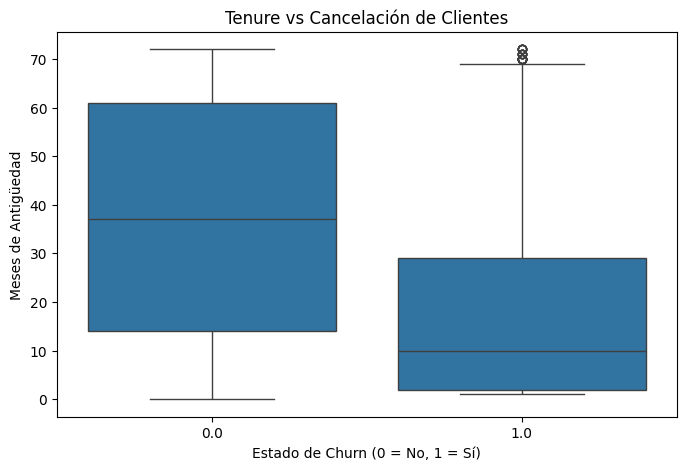

In [ ]:
# Boxplot Tenure vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='tenure', data=df)
plt.title('Tenure vs Cancelación de Clientes')
plt.xlabel('Estado de Churn (0 = No, 1 = Sí)')
plt.ylabel('Meses de Antigüedad')
plt.show()

El boxplot revela que los clientes que churnean suelen tener menor antigüedad con la empresa que los que permanecen. Esto indica que la relación comercial temprana es un factor crítico en la cancelación de servicio.

#### **Total Charges vs Churn**

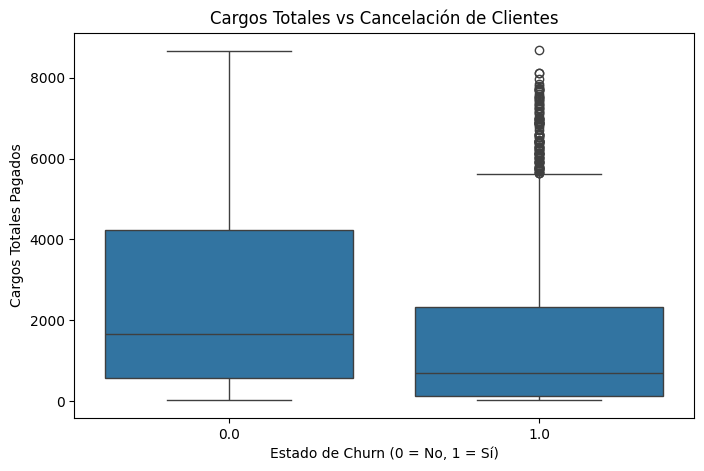

In [ ]:
# Boxplot Total Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='total_charges', data=df)
plt.title('Cargos Totales vs Cancelación de Clientes')
plt.xlabel('Estado de Churn (0 = No, 1 = Sí)')
plt.ylabel('Cargos Totales Pagados')
plt.show()

El boxplot de cargos totales muestra que quienes churnean han pagado menos en total, lo que sugiere que tienden a abandonar antes de acumular facturación significativa.

#### **Tenure y Total Charges en conjunto**

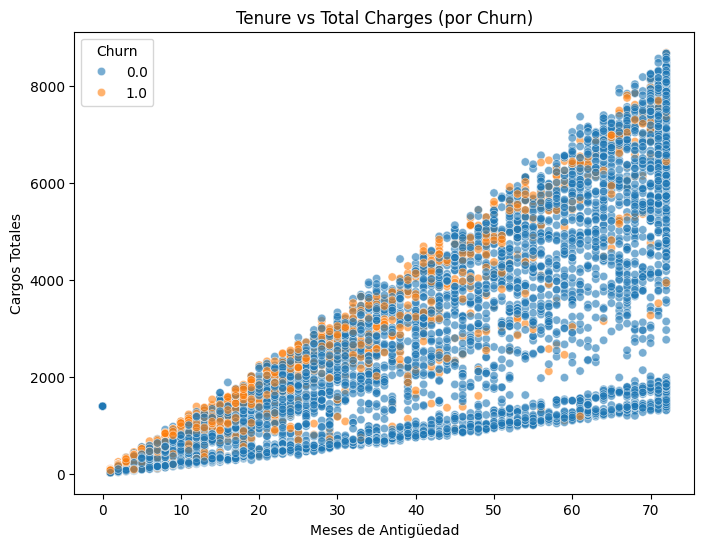

In [ ]:
# Scatter Tenure vs Total Charges
plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='total_charges', hue='churn', data=df, alpha=0.6)
plt.title('Tenure vs Total Charges (por Churn)')
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Cargos Totales')
plt.legend(title='Churn')
plt.show()

El scatter indica un patrón en el que clientes con mayor antigüedad y mayor gasto total suelen permanecer, mientras que los que churnean se concentran en menores valores de ambas dimensiones.

## 8. Evaluación de Multicolinealidad

Se analiza la presencia de multicolinealidad entre variables predictoras mediante el cálculo del **Variance Inflation Factor (VIF)**.

La multicolinealidad ocurre cuando una variable puede explicarse linealmente por otras variables del modelo, lo que puede:

- Inflar la varianza de los coeficientes
- Generar inestabilidad en la estimación
- Dificultar la interpretación del modelo

Regla práctica:

- VIF ≈ 1 → sin colinealidad
- VIF > 5 → posible problema
- VIF > 10 → problema real

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Creamos DataFrame solo con variables predictoras
X_vif = pd.DataFrame(X_train_bal, columns=X_train.columns)

In [ ]:
# Convertimos columnas booleanas a inter (0 or 1)
boolean_cols = X_vif.select_dtypes(include='bool').columns
X_vif[boolean_cols] = X_vif[boolean_cols].astype(int)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
# Ordenamos por VIF descendente
vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
26,streaming_movies_No,inf
24,streaming_tv_No,inf
18,online_backup_No,inf
20,device_protection_No,inf
16,online_security_No,inf
14,internet_service_No,inf
22,tech_support_No,inf
9,daily_charges,1.170438e+05
7,monthly_charges,1.170179e+05
4,phone_service,1.244163e+02


Datos de referencia:
1. **VIF = infinito** determina una colinealidad perfecta.
  - Ocurre porque:
    - Las variables _No están estructuralmente relacionadas.
    - Por ejemplo:
        - Si internet_service_No = 1
        - Entonces todos los servicios asociados también serán No.italicized text

2. ¿Por qué daily_charges tiene VIF muy alto?
  - Ocurre porque:
    - daily_charges y monthly_charges están correlacionadas ≈ 1. Son básicamente la misma variable en distinta escala.
    - Además total_charges depende de tenure × monthly_charges.

### 8.1 Eliminación de Variables Redundantes detectadas

Se eliminan variables con multicolinealidad perfecta o extremadamente alta, incluyendo:

- Variables derivadas matemáticamente (`daily_charges`, `total_charges`)
- Variables con dependencia estructural (`*_No`)

El objetivo es mejorar la estabilidad y la interpretabilidad del modelo.

In [ ]:
X_train_clean = X_train_bal.copy()
X_test_clean = X_test.copy()

In [ ]:
cols_to_drop = [
    'daily_charges',
    'total_charges',
    'streaming_movies_No',
    'streaming_tv_No',
    'online_backup_No',
    'device_protection_No',
    'online_security_No',
    'internet_service_No',
    'tech_support_No'
]

In [ ]:
X_train_clean = X_train_clean.drop(columns=cols_to_drop)
X_test_clean = X_test_clean.drop(columns=cols_to_drop)

### 8.2 Recalculamos el VIF con nuestro dataset limpio

Se eliminan variables con multicolinealidad perfecta o extremadamente alta, incluyendo:

- Variables derivadas matemáticamente (`daily_charges`, `total_charges`)
- Variables con dependencia estructural (`*_No`)

El objetivo es mejorar la estabilidad y la interpretabilidad del modelo.

In [ ]:
X_vif_clean = pd.DataFrame(X_train_clean, columns=X_train_clean.columns)

In [ ]:
vif_data_clean = pd.DataFrame()
vif_data_clean["feature"] = X_vif_clean.columns

# Convertimos columnas booleanas a inter (0 or 1)
boolean_cols_clean = X_vif_clean.select_dtypes(include='bool').columns
X_vif_clean[boolean_cols_clean] = X_vif_clean[boolean_cols_clean].astype(int)

vif_data_clean["VIF"] = [
    variance_inflation_factor(X_vif_clean.values, i)
    for i in range(X_vif_clean.shape[1])
]

In [ ]:
vif_data_clean.sort_values(by="VIF", ascending=False)

,feature,VIF
4,phone_service,28.097926
7,monthly_charges,12.171153
11,internet_service_Fiber optic,5.302061
10,multiple_lines_No,3.013119
3,tenure,2.872432
5,contract,2.395679
17,streaming_movies_1.0,2.090323
16,streaming_tv_1.0,2.049901
19,payment_method_Electronic check,1.964071
20,payment_method_Mailed check,1.678598


### 8.3 Ajuste Final por Multicolinealidad

Se elimina la variable `phone_service` debido a su alto VIF (>10), indicando dependencia estructural con otras variables del modelo.

El objetivo es mejorar la estabilidad de los coeficientes en la regresión logística.

In [ ]:
# Eliminar phone_service
X_train_clean = X_train_clean.drop(columns=['phone_service'])
X_test_clean = X_test_clean.drop(columns=['phone_service'])

In [ ]:
X_vif_clean = pd.DataFrame(X_train_clean, columns=X_train_clean.columns)

In [ ]:
vif_data_clean = pd.DataFrame()
vif_data_clean["feature"] = X_vif_clean.columns

boolean_cols_clean = X_vif_clean.select_dtypes(include='bool').columns
X_vif_clean[boolean_cols_clean] = X_vif_clean[boolean_cols_clean].astype(int)

vif_data_clean["VIF"] = [
    variance_inflation_factor(X_vif_clean.values, i)
    for i in range(X_vif_clean.shape[1])
]

In [ ]:
vif_data_clean.sort_values(by="VIF", ascending=False)

,feature,VIF
6,monthly_charges,33.167660
10,internet_service_Fiber optic,8.735213
3,tenure,6.481526
16,streaming_movies_1.0,3.325147
15,streaming_tv_1.0,3.302740
4,contract,3.257116
18,payment_method_Electronic check,3.234866
8,multiple_lines_1.0,2.981134
5,paperless_billing,2.869336
1,partner,2.450143


La variable `monthly_charges` presenta un VIF elevado (>30), indicando que puede explicarse casi completamente por otras variables del modelo (servicios contratados e internet).

Dado que el objetivo es mantener interpretabilidad granular y estabilidad estadística, se decide eliminar `monthly_charges` y conservar las variables desagregadas.

### 8.4 Eliminación Final de Variable Agregada

La variable `monthly_charges` presenta un VIF superior a 30, lo que indica que puede explicarse casi completamente por otras variables del modelo (servicios contratados y tipo de internet).

Dado que su información ya está representada de manera desagregada, se elimina para mejorar la estabilidad estadística e interpretabilidad del modelo.

In [ ]:
X_train_clean = X_train_clean.drop(columns=['monthly_charges'])
X_test_clean = X_test_clean.drop(columns=['monthly_charges'])

In [ ]:
X_vif_final = pd.DataFrame(X_train_clean, columns=X_train_clean.columns)

In [ ]:
vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_vif_final.columns

boolean_cols_final = X_vif_final.select_dtypes(include='bool').columns
X_vif_final[boolean_cols_final] = X_vif_final[boolean_cols_final].astype(int)

vif_data_final["VIF"] = [
    variance_inflation_factor(X_vif_final.values, i)
    for i in range(X_vif_final.shape[1])
]

In [ ]:
vif_data_final.sort_values(by="VIF", ascending=False)

,feature,VIF
3,tenure,6.414949
9,internet_service_Fiber optic,4.251709
4,contract,3.232094
14,streaming_tv_1.0,3.090852
15,streaming_movies_1.0,3.047119
7,multiple_lines_1.0,2.910964
17,payment_method_Electronic check,2.797388
5,paperless_billing,2.570857
1,partner,2.429763
6,gender_Male,2.256400


## 9. Estandarización de Variables

Se aplica estandarización mediante `StandardScaler` para asegurar que todas las variables numéricas se encuentren en la misma escala.

Esto es necesario para modelos basados en optimización y gradiente como la Regresión Logística, ya que variables con magnitudes mayores pueden dominar el proceso de entrenamiento.

El escalador se ajusta únicamente sobre el conjunto de entrenamiento para evitar fuga de información.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Inicializar escalador
scaler = StandardScaler()

# Ajustar solo en entrenamiento
X_train_scaled = scaler.fit_transform(X_train_clean)
# Transformar test con los parámetros del entrenamiento
X_test_scaled = scaler.transform(X_test_clean)

## 10. Modelado Predictivo

Se implementarán dos modelos distintos para la predicción de churn:

1. **Regresión Logística (con normalización)**  
   Modelo sensible a la escala de los datos. Se aplica estandarización para garantizar estabilidad numérica y correcta optimización de los coeficientes.

2. **Random Forest (sin normalización)**  
   Modelo basado en árboles que no depende de la escala de las variables, ya que divide los datos según umbrales y no por distancia.

### 10.1 Regresión Logística

Se entrena una Regresión Logística como modelo base.  
Este modelo es sensible a la escala de los datos, por lo que se utilizan las variables previamente estandarizadas.

Se incrementa el parámetro `max_iter` para asegurar convergencia del algoritmo de optimización.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train_bal)

LogisticRegression(max_iter=1000, random_state=42)

#### 10.1.2 Generación de Predicciones

Generamos:

- Predicciones binarias.
- Probabilidades estimadas de churn.

Las probabilidades permiten evaluar la capacidad discriminativa del modelo mediante la curva ROC y el AUC.

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

#### 10.1.3 Evaluación del Modelo

Evaluamos el desempeño utilizando múltiples métricas debido al desbalance original de clases.

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** proporción de predicciones positivas que realmente son churn.
- **Recall:** proporción de churn reales correctamente detectados.
- **F1-score:** balance entre precisión y recall.
- **ROC-AUC:** capacidad del modelo para distinguir entre clases.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.7599724896836314
Precision: 0.5272331154684096
Recall: 0.6470588235294118
F1 Score: 0.581032412965186
ROC-AUC: 0.8232100415923945


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.87      0.80      0.83      1080
         1.0       0.53      0.65      0.58       374

    accuracy                           0.76      1454
   macro avg       0.70      0.72      0.71      1454
weighted avg       0.78      0.76      0.77      1454



#### 10.1.4 Curva ROC

Visualizamos la curva ROC para evaluar la capacidad del modelo de distinguir entre clientes que cancelan y los que no.

Un AUC cercano a 1 indica excelente capacidad discriminativa.

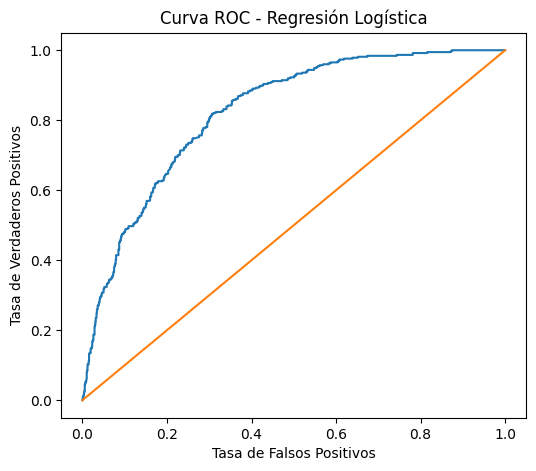

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("Curva ROC - Regresión Logística")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.show()

### Conclusión de nuestro **Modelo de Regresión Logística**

La Regresión Logística muestra:

- Buen poder discriminativo (ROC-AUC ≈ 0.82)
- Capacidad razonable para detectar churn (Recall ≈ 65%)
- Precisión moderada en la identificación de cancelaciones (Precision ≈ 53%)

El modelo logra un equilibrio adecuado entre detección de churn y control de falsos positivos, funcionando como una baseline sólida y altamente interpretable.

### 10.2 Random Forest

Se entrena un modelo Random Forest como alternativa no lineal.

Este modelo:

- No requiere estandarización.
- Es robusto ante colinealidad moderada.
- Captura interacciones y relaciones no lineales entre variables.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

# Entrenamos con el conjunto balanceado (SMOTE)
rf_model.fit(X_train_clean, y_train_bal)

RandomForestClassifier(n_estimators=200, random_state=42)

#### 10.2.1 Generación de Predicciones

Se generan predicciones binarias y probabilidades estimadas de churn utilizando el modelo Random Forest.

In [ ]:
# Predicciones binarias
y_pred_rf = rf_model.predict(X_test_clean)

# Probabilidades estimadas de churn
y_prob_rf = rf_model.predict_proba(X_test_clean)[:, 1]

#### 10.2.2 Evaluación del Modelo

Evaluamos el modelo Random Forest utilizando las mismas métricas empleadas en la Regresión Logística para garantizar una comparación justa.

Se analizan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [ ]:
# Cálculo de métricas principales
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Mostrar métricas
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)

Accuracy: 0.7702888583218707
Precision: 0.5497512437810945
Recall: 0.5909090909090909
F1 Score: 0.5695876288659794
ROC-AUC: 0.809623192711428


In [ ]:
# Reporte detallado por clase
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84      1080
         1.0       0.55      0.59      0.57       374

    accuracy                           0.77      1454
   macro avg       0.70      0.71      0.71      1454
weighted avg       0.78      0.77      0.77      1454



### 10.3 Matriz de Confusión

La matriz de confusión permite visualizar:

- Verdaderos Positivos (TP)
- Verdaderos Negativos (TN)
- Falsos Positivos (FP)
- Falsos Negativos (FN)

Es especialmente importante en problemas de churn, donde los falsos negativos representan clientes que cancelan y no fueron detectados.

#### 10.3.1 Regresión Loística

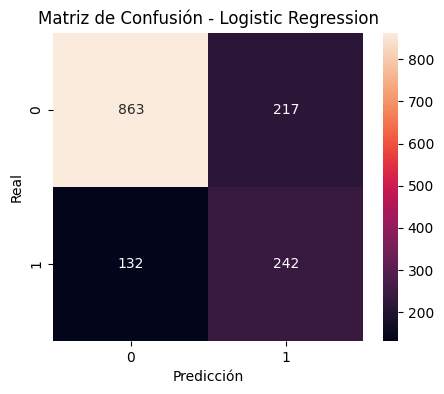

In [ ]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### 10.3.2 Random Forest

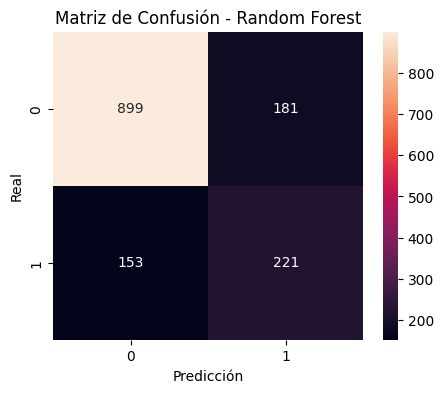

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### 10.4 Evaluación de Overfitting y Underfitting

Se comparan las métricas obtenidas en el conjunto de entrenamiento y prueba.

- **Overfitting:** rendimiento alto en entrenamiento pero bajo en prueba.
- **Underfitting:** bajo rendimiento tanto en entrenamiento como en prueba.

#### 10.4.1 Evaluación Train vs Test - **Modelo de Regresión Logística**

In [ ]:
# Predicciones en entrenamiento
y_pred_train_log = log_model.predict(X_train_scaled)

print("Accuracy Train:", accuracy_score(y_train_bal, y_pred_train_log))
print("Accuracy Test:", accuracy_score(y_test, y_pred_log))

Accuracy Train: 0.8075497915701714
Accuracy Test: 0.7599724896836314


#### 10.4.2 Evaluación Train vs Test - **Modelo Random Forest**

In [ ]:
y_pred_train_rf = rf_model.predict(X_train_clean)

print("Accuracy Train:", accuracy_score(y_train_bal, y_pred_train_rf))
print("Accuracy Test:", accuracy_score(y_test, y_pred_rf))

Accuracy Train: 0.9760305697081982
Accuracy Test: 0.7702888583218707


#### Análisis de Overfitting y Underfitting

**Regresión Logística:**
- Accuracy Train ≈ 0.81
- Accuracy Test ≈ 0.76
- Diferencia moderada (~5%)

*Conclusión:*
El modelo generaliza adecuadamente y no presenta evidencia significativa de overfitting.

**Random Forest:**
- Accuracy Train ≈ 0.98
- Accuracy Test ≈ 0.77
- Diferencia considerable (~21%)

*Conclusión:*
El modelo presenta overfitting, ya que aprende excesivamente el conjunto de entrenamiento y pierde capacidad de generalización.

### 10.5 Ajuste del Random Forest

Se ajustan hiperparámetros del modelo para reducir el overfitting detectado:

- Se limita la profundidad máxima del árbol (`max_depth`).
- Se incrementa el número mínimo de muestras por hoja (`min_samples_leaf`).
- Se ajusta el mínimo de muestras para dividir un nodo (`min_samples_split`).

El objetivo es mejorar la capacidad de generalización del modelo.

In [ ]:
# Modelo con control de complejidad
rf_model_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Entrenamiento
rf_model_tuned.fit(X_train_clean, y_train_bal)

RandomForestClassifier(max_depth=8, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=300, random_state=42)

#### 10.5.1 Evaluación del Random Forest Regularizado

Evaluamos el modelo ajustado utilizando las mismas métricas que en los modelos anteriores:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de confusión

El objetivo es verificar si el ajuste de hiperparámetros redujo el overfitting y mejoró la generalización.

In [ ]:
# Predicciones en test
y_pred_rf_tuned = rf_model_tuned.predict(X_test_clean)
y_prob_rf_tuned = rf_model_tuned.predict_proba(X_test_clean)[:, 1]

# Métricas principales
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))

# Reporte detallado
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_tuned))

Accuracy: 0.7716643741403026
Precision: 0.5426829268292683
Recall: 0.713903743315508
F1 Score: 0.6166281755196305
ROC-AUC: 0.8397553971083382

Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84      1080
         1.0       0.54      0.71      0.62       374

    accuracy                           0.77      1454
   macro avg       0.72      0.75      0.73      1454
weighted avg       0.80      0.77      0.78      1454



### 10.5.2 Evaluación Train vs Test

Comparamos el desempeño del modelo regularizado en entrenamiento y prueba para verificar si el overfitting fue reducido.

In [ ]:
# Predicción en entrenamiento
y_pred_train_rf_tuned = rf_model_tuned.predict(X_train_clean)

print("Accuracy Train:", accuracy_score(y_train_bal, y_pred_train_rf_tuned))
print("Accuracy Test:", accuracy_score(y_test, y_pred_rf_tuned))

Accuracy Train: 0.8385826771653543
Accuracy Test: 0.7716643741403026


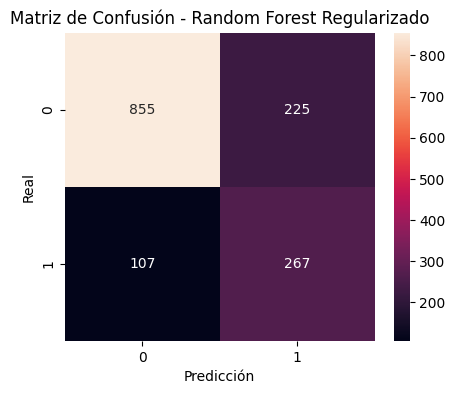

In [ ]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_tuned,annot=True,fmt="d")

plt.title("Matriz de Confusión - Random Forest Regularizado")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### Interpretación de la Matriz de Confusión – Random Forest Regularizado

Resultados obtenidos:

- Verdaderos Negativos (TN): 855
- Falsos Positivos (FP): 225
- Falsos Negativos (FN): 107
- Verdaderos Positivos (TP): 267

Interpretación:

- El modelo detecta correctamente 267 de 374 clientes que cancelan (Recall ≈ 71%).
- Solo 107 clientes que cancelan no fueron detectados (FN).
- Se generan 225 falsos positivos, es decir, clientes marcados como riesgo que finalmente no cancelan.

En problemas de churn, es preferible reducir los falsos negativos, ya que representan pérdida directa de clientes.

### 10.5 Comparación de Modelos

Se compararon tres configuraciones:

1. Regresión Logística
2. Random Forest original
3. Random Forest regularizado

El Random Forest regularizado presentó:

- Mejor ROC-AUC (0.84)
- Mayor Recall para la clase churn (0.71)
- Mejor F1-score
- Reducción significativa del overfitting (gap train-test ≈ 6%)

Conclusión:
El Random Forest regularizado es el modelo con mejor desempeño general y mejor capacidad de generalización. Por lo tanto será nuestro modelo champion.

### 10.6 Importancia de Variables – Random Forest Regularizado

In [ ]:
# Extraer importancias
importances = rf_model_tuned.feature_importances_

# Crear DataFrame
feature_importance_df = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': importances
})

In [ ]:
# Ordenar de mayor a menor
feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance_df.head(15))

                                   feature  importance
4                                 contract    0.290397
17         payment_method_Electronic check    0.184231
3                                   tenure    0.162813
9             internet_service_Fiber optic    0.118959
2                               dependents    0.054309
1                                  partner    0.043300
14                        streaming_tv_1.0    0.024114
7                       multiple_lines_1.0    0.021082
15                    streaming_movies_1.0    0.017524
16  payment_method_Credit card (automatic)    0.013757
6                              gender_Male    0.012230
18             payment_method_Mailed check    0.010815
8                        multiple_lines_No    0.008790
12                   device_protection_1.0    0.007832
13                        tech_support_1.0    0.006673


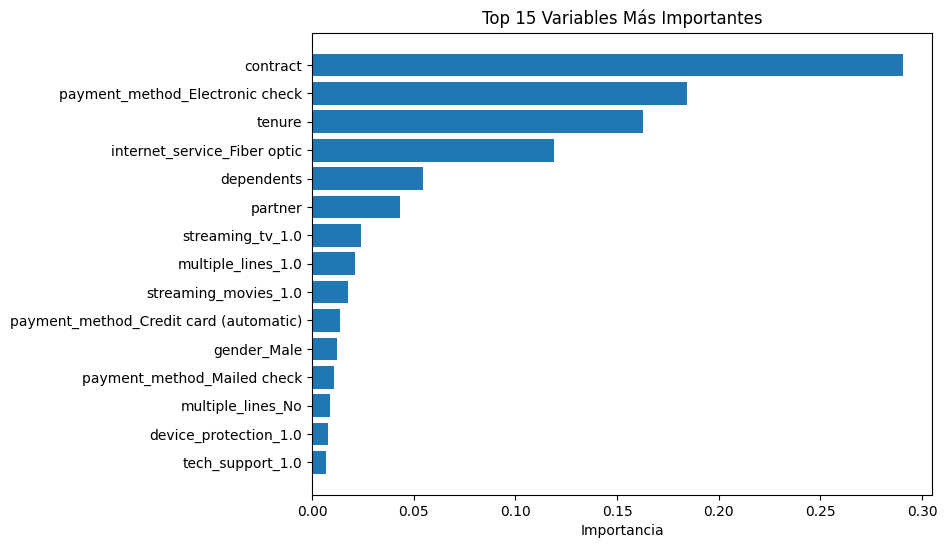

In [ ]:
# Gráfico de Importancia

top_features = feature_importance_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Variables Más Importantes")
plt.xlabel("Importancia")
plt.show()

Después de analizar la importancia relativa de cada variable en la predicción de churn.

Las variables más relevantes fueron:

1. Contract.
2. Payment Method (*Electronic Check*).
3. Tenure.
4. Internet Service (*Fiber Optic*).
5. Dependents.
6. Partner.

Interpretación:

- Las variables contractuales y de permanencia son los principales determinantes del churn.
- El método de pago tiene una influencia significativa.
- Variables demográficas tienen impacto secundario.

**Insight Importante**

El churn está principalmente explicado por variables contractuales y de permanencia, más que por características demográficas.

Las acciones prioritarias deberían enfocarse en:

- Migrar clientes a contratos de mayor duración.
- Incentivar métodos de pago automáticos.
- Implementar estrategias de retención temprana.

## 11. Informe Final – Análisis de Cancelación de Clientes

### 1. Evaluación de Modelos

Se evaluaron tres configuraciones:

- Regresión Logística
- Random Forest original
- Random Forest regularizado

El Random Forest regularizado presentó el mejor desempeño general:

- Accuracy ≈ 0.77
- Recall ≈ 0.71
- F1-score ≈ 0.62
- ROC-AUC ≈ 0.84
- Reducción significativa del overfitting

Este modelo logra un equilibrio adecuado entre detección de clientes en riesgo y capacidad de generalización.

### 2. Principales Factores que Influyen en la Cancelación

Las variables más relevantes identificadas por el modelo fueron:

1. Contract
2. Payment Method (Electronic Check)
3. Tenure
4. Internet Service (Fiber Optic)
5. Dependents
6. Partner

Estos resultados indican que el churn está principalmente asociado a:

- Tipo y duración del contrato.
- Método de pago.
- Tiempo de permanencia.
- Tipo de servicio contratado.

### 3. Estrategias de Retención Propuestas

Con base en los resultados obtenidos, se proponen las siguientes acciones:

1. Incentivar la migración de contratos mensuales a contratos anuales mediante descuentos o beneficios adicionales.

2. Promover métodos de pago automáticos (tarjeta o débito automático) para aumentar la estabilidad y reducir churn asociado a Electronic Check.

3. Implementar estrategias de retención temprana durante los primeros meses del cliente (seguimiento personalizado, promociones iniciales).

4. Monitorear de forma preventiva a clientes con servicio Fiber Optic, especialmente si presentan bajo tenure.

Estas acciones están alineadas con los factores estructurales que el modelo identificó como principales determinantes del churn. En conclusión, **el churn es un fenómeno estructural y gestionable mediante decisiones estratégicas de negocio.**